# Weekly Permian Basin methane emissions inferred from TROPOMI satellite data

Varon et al. (2025) [preprint] https://eartharxiv.org/repository/view/9533/

In [1]:
import numpy as np
import os
import xarray as xr
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import colorcet as cc
from utils import moving_average, get_posterior_emissions, get_annual_emissions

## State vector

In [2]:
# Load state vector file
state_vector = xr.load_dataset("StateVector.nc")["StateVector"]

# Create Permian mask
# State vector includes 16 large emisson elements outside the Permian
last_permian_element = state_vector.max().values - 16 
mask = state_vector <= last_permian_element

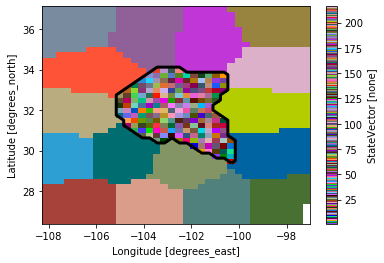

In [3]:
# Plot state vector and Permian mask
state_vector.plot(cmap=cc.cm.glasbey_dark)
mask.plot.contour(levels=1, colors="k", linewidths=3);

## Weekly total emission estimates

In [ ]:
df = pd.read_csv("weekly_total_emissions.csv")
df.head()

,period_number,period_start,period_end,dt_middle,prior_emission(Tg/a),kf_prior_emission(Tg/a),posterior_emission(Tg/a),oil/gas(Tg/a),livestock(Tg/a),waste(Tg/a),other(Tg/a)
0,1,20180705,20180712,2018-07-08 12:00:00,1.124008,1.124008,1.136561,0.902347,0.138857,0.023651,0.071706
1,2,20180712,20180719,2018-07-15 12:00:00,1.124064,1.136618,2.100002,1.756958,0.185109,0.027701,0.130233
2,3,20180719,20180726,2018-07-22 12:00:00,1.124029,2.100038,4.030116,3.490934,0.260054,0.053947,0.225185
3,4,20180726,20180802,2018-07-29 12:00:00,1.123208,4.029950,3.131313,2.659312,0.214177,0.066351,0.191471
4,5,20180802,20180809,2018-08-05 12:00:00,1.118234,3.132289,2.748651,2.316798,0.197543,0.062685,0.171627


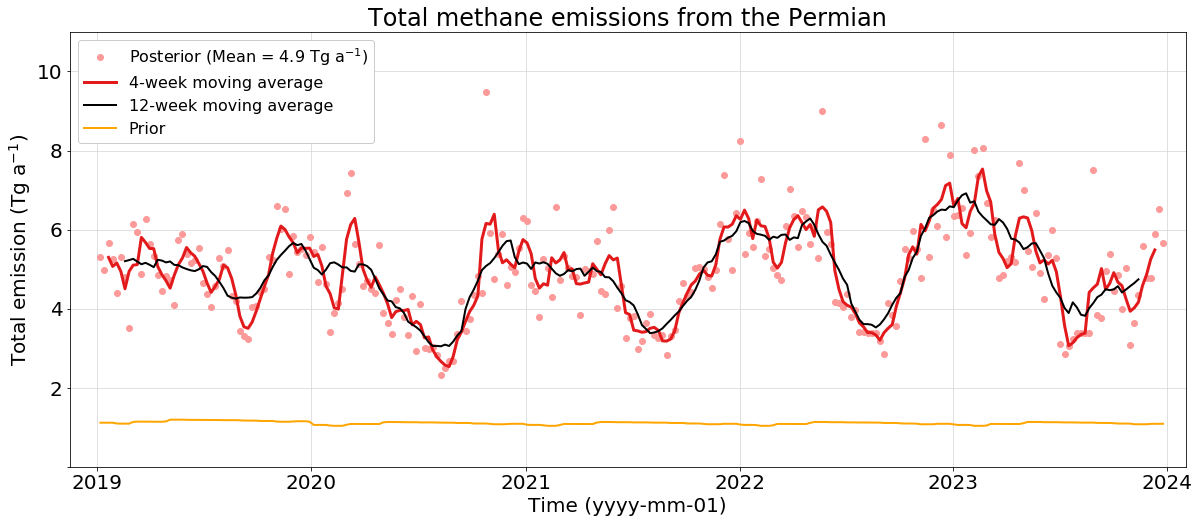

In [5]:
# Plot weekly estimates
fig = plt.figure(figsize=(20,8))
plt.rcParams.update({'font.size': 20})
ax = fig.subplots(1,1)

# Name variables
dt = pd.to_datetime(df["dt_middle"])
posterior_emis = df["posterior_emission(Tg/a)"]
prior_emis = df["prior_emission(Tg/a)"]

# Colors
c5 = np.array([251,154,153])/255
c6 = np.array([227,26,28])/255

# First period to consider
# Count from 0
# fp = 26 means the first 6 months of results are discarded as Kalman filter "burn-in"
fp = 26 

# line/marker options
lw = 3
ms = 12

# Time series
ax.plot(dt[fp:], posterior_emis[fp:], "o", color=c5,
        label=f"Posterior (Mean = {np.round(np.mean(posterior_emis[fp:]),1)}"+" Tg a$^{-1}$)")
ax.plot(dt[fp:][2:-2], moving_average(posterior_emis[fp:], 4)[2:-2], "-", color=c6, lw=lw, ms=ms,
        label="4-week moving average")
ax.plot(dt[fp:][6:-6], moving_average(posterior_emis[fp:], 12)[6:-6], "-", color="k", lw=lw-1, ms=ms,
        label="12-week moving average")
ax.plot(dt[fp:], prior_emis[fp:], "-", lw=lw-1, color="orange",
        label="Prior")

ax.legend(ncol=1, fontsize=16, framealpha=1)
ax.set_ylabel("Total emission (Tg a$^{-1}$)")
ax.set_ylim([0,11])
ax.set_yticks([0,2,4,6,8,10])
ax.set_yticklabels(['',2,4,6,8,10])
ax.set_xlabel("Time (yyyy-mm-01)")
ax.set_xlim([datetime.datetime(2018,11,15), datetime.datetime(2024,2,1)])
ax.set_title("Total methane emissions from the Permian")

ax.grid(color=[.85,.85,.85], zorder=1);

### Map one week of posterior emissions at 25-km resolution

In [6]:
# Select week index
# Count from 1
# p = 27 selects the first week after a 6-month burn-in period
p = 27

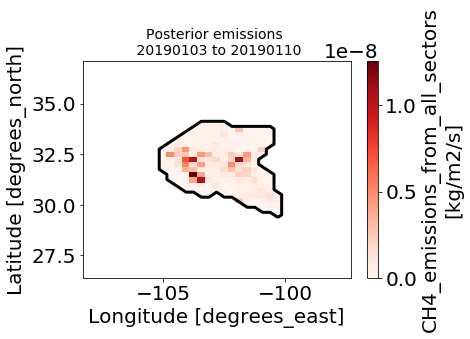

In [7]:
# Get posterior emissions for a period p
sf_post = xr.load_dataset(os.path.join("scale_factors", f"posterior_sf_period{p}.nc"))
start = df.loc[df["period_number"] == p]["period_start"].values[0]
end = df.loc[df["period_number"] == p]["period_end"].values[0]
hemco_file = os.path.join("hemco_emissions", f"HEMCO_diagnostics.{start}0000.nc")
hemco_diags = xr.load_dataset(hemco_file)
post_emis = get_posterior_emissions(hemco_diags, sf_post)
post_emis = post_emis["EmisCH4_Total"].isel(time=0, drop=True) - post_emis["EmisCH4_SoilAbsorb"]

# Remove buffer elements outside Permian, which may return unphysical negative emissions
post_emis = post_emis.where((state_vector <= last_permian_element))

# Plot the emissions
post_emis.plot(vmin=0, cmap="Reds")
mask.plot.contour(levels=1, colors="k", linewidths=3)
plt.title(f"Posterior emissions \n {start} to {end}", fontsize=14);

### Inspect posterior error covariance and averaging kernel matrices for the week

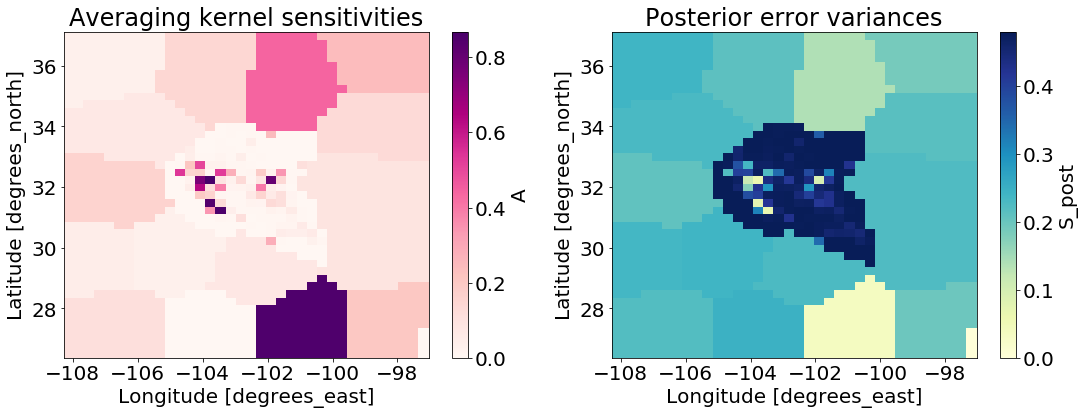

In [8]:
# Open the gridded posterior and diagnostics (averaging kernel A and posterior error covariance matrix S) for a period p
posterior_diagnostics = xr.load_dataset(f"inversion_diagnostics/gridded_posterior_ln_period{p}.nc")

# Plot A and S_post
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(18,6))
plt.rcParams.update({'font.size': 20})
posterior_diagnostics["A"].plot(cmap="RdPu", ax=ax1)
posterior_diagnostics["S_post"].plot(cmap="YlGnBu", ax=ax2)
ax1.set_title("Averaging kernel sensitivities")
ax2.set_title("Posterior error variances");

In [9]:
# Load the full averaging kernel (A) and posterior error covariance (S_post) matrices
full_inversion_results = xr.load_dataset(f"inversion_diagnostics/inversion_result_ln_period{p}.nc")
full_inversion_results

<xarray.Dataset>
Dimensions:  (float: 1, nvar: 220)
Dimensions without coordinates: float, nvar
Data variables:
    xhat     (nvar) float32 1.005562 1.012289 1.0077367 ... 1.9685329 3.6181405
    lnxn     (nvar) float32 0.0055553904 0.012360691 ... 1.9685329 3.6181405
    S_post   (nvar, nvar) float32 0.48043528 -3.4806546e-06 ... 0.07409327
    A        (nvar, nvar) float32 3.688024e-05 7.244527e-06 ... 0.99925905
    DOFS     (float) float32 19.535948
    Ja       (float) float32 24.597906

A matrix has shape (220, 220)
S matrix has shape (220, 220)


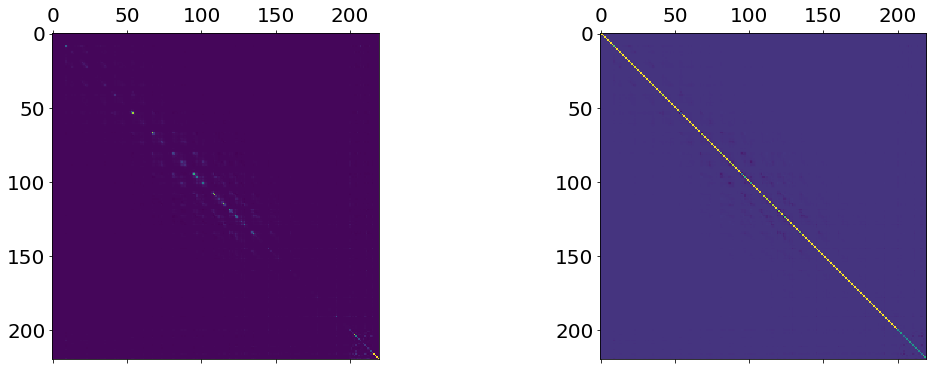

In [10]:
# Visualize A and S_post
A = full_inversion_results["A"]
S_post = full_inversion_results["S_post"]

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(18,6))
plt.rcParams.update({'font.size': 20})
ax1.matshow(A)
ax2.matshow(S_post)

print(f"A matrix has shape {A.shape}")
print(f"S matrix has shape {S_post.shape}")

## Annual total emission estimates

In [11]:
# Compute annual mean, median, and standard deviation of weekly total emission estimates
years = [2019, 2020, 2021, 2022, 2023]
emis, mean_emis, std_emis, median_emis = get_annual_emissions(dt, posterior_emis, years)
df_annual = pd.DataFrame(list(zip(years, mean_emis, median_emis, std_emis)), columns=["Year", "Mean(Tg/a)", "Median(Tg/a)", "Std(Tg/a)"])
df_annual

,Year,Mean(Tg/a),Median(Tg/a),Std(Tg/a)
0,2019,5.013448,5.194174,0.792265
1,2020,4.448963,4.396079,1.322305
2,2021,4.633538,4.620389,1.013639
3,2022,5.359460,5.446228,1.460837
4,2023,5.177243,5.186544,1.358274


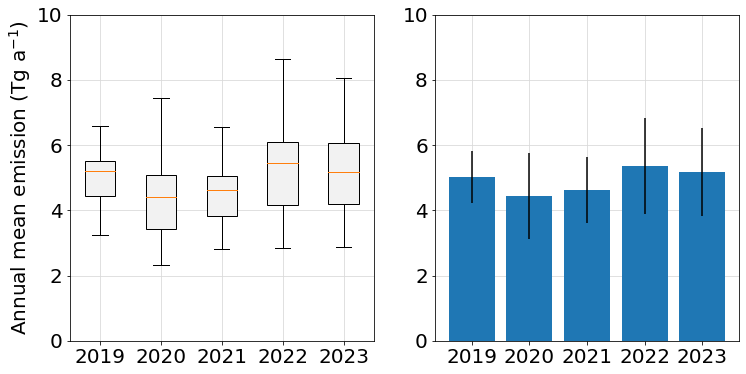

In [12]:
# Plot results -- bar plot and box/whisker plot
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,6))
plt.rcParams.update({'font.size': 20})

# Box and whisker
bplot = ax1.boxplot([emis[2019], emis[2020], emis[2021], emis[2022], emis[2023]], showfliers=False, patch_artist=True)
# Fill with color
col = [.95, .95, .95]
colors = [col, col, col, col, col]
for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        ax1.set_xticklabels(years)
ax1.grid(color=[.85,.85,.85])
ax1.set_ylim([0,10])
ax1.set_ylabel("Annual mean emission (Tg a$^{-1}$)");

# Bar
ax2.bar(years, mean_emis, zorder=10) 
ax2.errorbar(years, mean_emis, yerr=std_emis, fmt="none", color="k", zorder=11)
ax2.grid(color=[.85,.85,.85], zorder=0)
ax2.set_ylim([0,10])
ax2.set_xticks(years)
ax2.set_xticklabels(years);

## Weekly emission estimates by sector

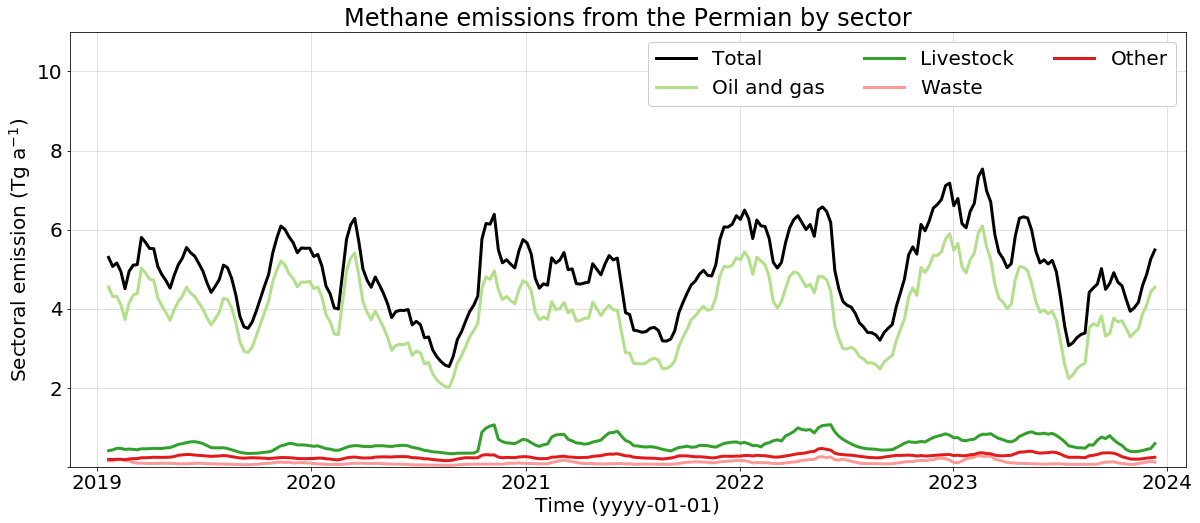

In [ ]:
# Plot sectoral emission time series
fig = plt.figure(figsize=(20,8))
plt.rcParams.update({'font.size': 20})
ax = fig.subplots(1,1)

# Colors
c3 = np.array([178,223,138])/255
c4 = np.array([51,160,44])/255
c5 = np.array([251,154,153])/255
c6 = np.array([227,26,28])/255

# First period to consider
# Count from 0
# fp = 26 means the first 6 months of results are discarded as Kalman filter "burn-in"
fp = 26

# Line/marker options
lw = 3
ms = 12

# Time series
ax.plot(dt[fp:][2:-2], moving_average(posterior_emis[fp:], 4)[2:-2], "-", color="k", lw=lw, ms=ms,
        label="Total")
ax.plot(dt[fp:][2:-2], moving_average(df["oil/gas(Tg/a)"][fp:], 4)[2:-2], "-", color=c3, lw=lw, ms=ms,
        label="Oil and gas")
ax.plot(dt[fp:][2:-2], moving_average(df["livestock(Tg/a)"][fp:], 4)[2:-2], "-", color=c4, lw=lw, ms=ms,
        label="Livestock")
ax.plot(dt[fp:][2:-2], moving_average(df["waste(Tg/a)"][fp:], 4)[2:-2], "-", color=c5, lw=lw, ms=ms,
        label="Waste")
ax.plot(dt[fp:][2:-2], moving_average(df["other(Tg/a)"][fp:], 4)[2:-2], "-", color=c6, lw=lw, ms=ms,
        label="Other")

ax.legend(ncol=3, fontsize=20, framealpha=1)
ax.set_ylabel("Sectoral emission (Tg a$^{-1}$)")
ax.set_ylim([0,11])
ax.set_yticks([0,2,4,6,8,10])
ax.set_yticklabels(['',2,4,6,8,10])
ax.set_xlabel("Time (yyyy-01-01)")
ax.set_xlim([datetime.datetime(2018,11,15), datetime.datetime(2024,2,1)])
ax.set_title("Methane emissions from the Permian by sector")

ax.grid(color=[.85,.85,.85], zorder=1);

## Annual oil and gas emission

In [14]:
# Compute annual mean, median, standard deviation of weekly estimates
years = [2019, 2020, 2021, 2022, 2023]
emis_oilgas, mean_emis_oilgas, std_emis_oilgas, median_emis_oilgas = get_annual_emissions(dt, df["oil/gas(Tg/a)"], years)
df_annual_oilgas = pd.DataFrame(list(zip(years, mean_emis_oilgas, median_emis_oilgas, std_emis_oilgas)), columns=["Year", "Mean(Tg/a)", "Median(Tg/a)", "Std(Tg/a)"])
df_annual_oilgas

,Year,Mean(Tg/a),Median(Tg/a),Std(Tg/a)
0,2019,4.206030,4.276309,0.711715
1,2020,3.634296,3.574803,1.085732
2,2021,3.688480,3.700013,0.873563
3,2022,4.235558,4.284356,1.241520
4,2023,4.105950,4.090884,1.166577


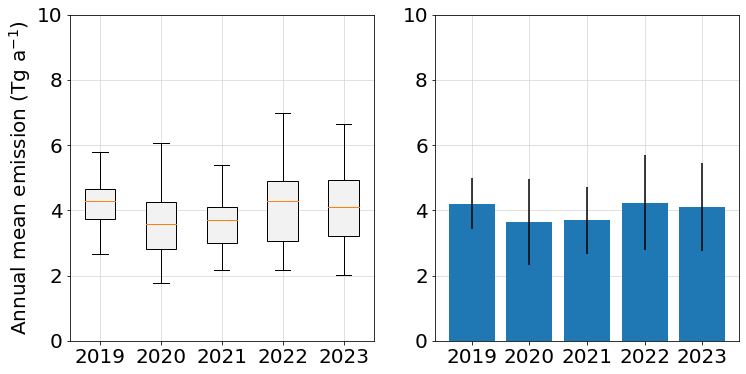

In [15]:
# Create bar plot and box and whisker plot
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,6))
plt.rcParams.update({'font.size': 20})

# Box and whisker
bplot = ax1.boxplot([emis_oilgas[2019], emis_oilgas[2020], emis_oilgas[2021], emis_oilgas[2022], emis_oilgas[2023]], showfliers=False, patch_artist=True)
# Fill with color
col = [.95, .95, .95]
colors = [col, col, col, col, col]
for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        ax1.set_xticklabels(years)
ax1.grid(color=[.85,.85,.85])
ax1.set_ylim([0,10])
ax1.set_ylabel("Annual mean emission (Tg a$^{-1}$)");

# Bar
ax2.bar(years, mean_emis_oilgas, zorder=10) 
ax2.errorbar(years, mean_emis_oilgas, yerr=std_emis, fmt="none", color="k", zorder=11)
ax2.grid(color=[.85,.85,.85], zorder=0)
ax2.set_ylim([0,10])
ax2.set_xticks(years)
ax2.set_xticklabels(years);

----